In [8]:
import os
import math
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
import tqdm
%matplotlib inline
from IPython.display import clear_output
from typing import List, Tuple, Optional
import matplotlib.ticker as mticker


os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_folder = "drive/MyDrive/mestrado_final_files/models/NGramModel/"
# models_token_metrics_folder = "drive/MyDrive/mestrado_final_files/metrics_models/NGramModel/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_token_folder = "G:\Meu Drive\mestrado_final_files\models\\NGramModel\\"
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel\\"

#models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"

In [2]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

# Convert the index of tokens_info to a list of tokens
list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}

# tokens_info = tokens_info\
# .query("hpts != 0 or vpts != 0 or limhteam != 0 or limvteam != 0")\
# .to_dict(orient = 'index')


In [3]:
tokens_limhteam_p = [ 21,  23,  39,  41, 267, 269, 271, 381, 383, 385, 387, 389, 390, 393, 395, 442, 444,
                            446, 448, 450, 452, 453, 456, 458, 460, 464, 478, 483, 488, 492, 497, 499, 501, 505]

# se limvteam == 0, entao a mascara tem que anular:# 34 tokens
tokens_limvteam_p = [ 20,  22,  38,  40, 266, 268, 270, 382, 384, 386, 388, 391, 392, 394, 396, 443, 445,
                            447, 449, 451, 454, 455, 457, 459, 461, 465, 479, 484, 489, 493, 498, 500, 502, 506]

# se limhteam == 1, entao a mascara tem que anular: # 57  tokens
tokens_limhteam_a = [ 15,  17,  19,  31,  33,  35,  37,  51,  53,  57,  59, 139, 161, 253, 255, 263, 265,
                        365, 367, 368, 371, 372, 373, 377, 378, 397, 399, 401, 403, 405, 407, 409, 411, 412,
                        415, 416, 419, 420, 421, 422, 426, 428, 430, 432, 434, 435, 438, 440, 462, 476, 480,
                        481, 486, 490, 494, 496, 503]

# se limvteam == 1, entao a mascara tem que anular: # 55 tokens
tokens_limvteam_a = [ 14,  16,  18,  30,  32,  34,  36,  50,  52,  56,  58, 138, 160, 252, 254, 256, 262,
                        264, 366, 369, 370, 374, 375, 376, 379, 380, 398, 400, 402, 404, 406, 408, 410, 413,
                        414, 417, 418, 423, 424, 425, 427, 429, 431, 433, 436, 437, 439, 441, 463, 477, 482,
                        487, 491, 495, 504]



In [4]:
tokens_info\
.reset_index()\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.query("index in @tokens_limhteam_a or index in @tokens_limvteam_a")

,index,token,n,cnt,cod,hpts,vpts,limhteam,limvteam
13,14,p400_1(3)p541_6(11a),2,1385,_1(3)_6(11a),2,0,0,-1
14,15,p500_1(3)p451_6(11a),2,1407,_1(3)_6(11a),0,2,-1,0
15,16,p400_1(3)p541_6(11a)p400_3(11c),3,1370,_1(3)_6(11a)_3(11c),3,0,0,-1
16,17,p500_1(3)p451_6(11a)p500_3(11c),3,1460,_1(3)_6(11a)_3(11c),0,3,-1,0
17,18,p400_1(3)p541_6(11a)p400_3(11w),3,429,_1(3)_6(11a)_3(11w),2,0,0,-1
...,...,...,...,...,...,...,...,...,...
493,494,p451_6(21a),1,2366,_6(21a),0,0,-1,0
494,495,p541_6(21a),1,2342,_6(21a),0,0,0,-1
495,496,p451_6(21a)p440_8(0),2,483,_6(21a)_8(0),0,0,-1,0
502,503,p451_6(22a),1,137,_6(22a),0,0,-1,0


In [5]:
with open(data_folder + 'data_token_features.pkl', 'rb') as f:
    df_token_features = pickle.load(f)


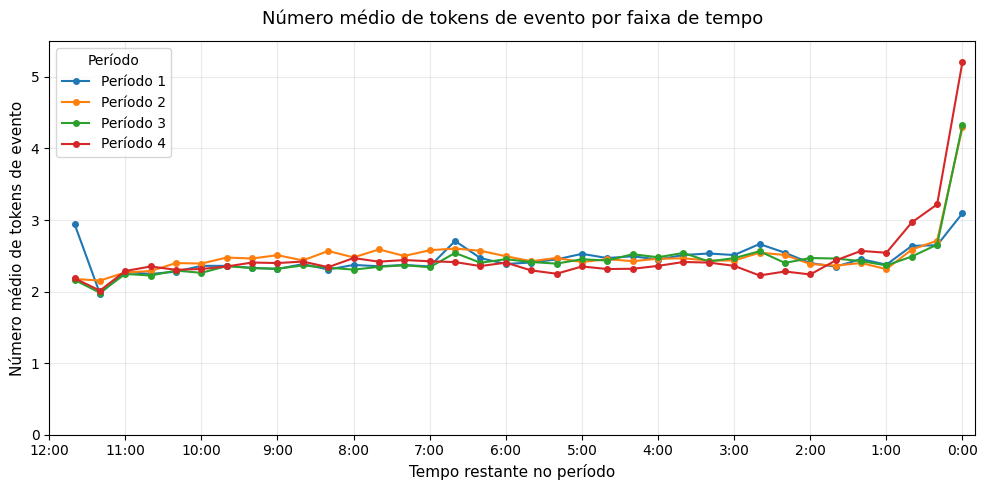

In [ ]:
def format_time_seconds(x, pos=None):
    x = int(round(x))
    minutes = x // 60
    seconds = x % 60
    return f"{minutes}:{seconds:02d}"

def get_match_splits(df, num_secs = 300):
    num_breaks = [i for i in range(0, 7201, num_secs)]
    num_labels = [str(i) + "-" + str(j) for i, j in zip(num_breaks[:-1], num_breaks[1:])]
    num_breaks[0] -= 1
    num_breaks[-1] += 1
    return df.assign(cat_time = lambda df: pd.cut(df["remaining_time"], bins = num_breaks, labels = num_labels))

df_plot_tokens = (
    df_token_features
    .query("season == '2022-23' & season_split == 'train'")
    .query("period <= 5")
    .pipe(func=get_match_splits, num_secs=200)
    .assign(
        num_games=lambda df: df.groupby("period")["game_id"].transform("nunique"),
        t1=lambda df: df["cat_time"].str.split("-").str[0].astype(int),
        t1_seconds=lambda df: df["t1"] / 10
    )
    .groupby(
        ["period", "cat_time", "t1", "t1_seconds", "num_games"],
        as_index=False,
        dropna=False,
        observed=True
    )
    .size()
    .assign(media_tokens=lambda df: df["size"] / df["num_games"])
    .sort_values(["period", "t1"], ascending=[True, False])
)

fig, ax = plt.subplots(figsize=(10, 5))

for period in [1, 2, 3, 4]:
    df_period = df_plot_tokens.query("period == @period")

    if df_period.empty:
        continue

    label = f"Período {period}"

    ax.plot(
        df_period["t1_seconds"],
        df_period["media_tokens"],
        marker="o",
        linewidth=1.5,
        markersize=4,
        label=label
    )

ax.set_title(
    "Número médio de tokens de evento por faixa de tempo",
    fontsize=13,
    pad=12
)

ax.set_xlabel("Tempo restante no período", fontsize=11)
ax.set_ylabel("Número médio de tokens de evento", fontsize=11)

# Mesmo eixo x do gráfico de incerteza
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Eixo y com zoom controlado
ax.set_ylim(0, 5.5)

ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

plt.tight_layout()

# plt.savefig(
#     "img/media_tokens_tempo_jogo.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [ ]:
df_token_features.query("season == @season").query("season_split == 'dev'")\
.assign(token = lambda df: df["target_tokens"].map(integer_to_token))\
.assign(last_token = lambda df: df.groupby(["game_id", "period"])["token"].shift(1))\
.query("last_token.notna() & last_token.str.contains('_2\(.{,2}\)$')")

In [15]:
list_models = [item for item in os.listdir(models_token_folder) if "NGramModel" in item and ".pth" in item]
model_filename = list_models[0]

In [16]:
model_filename

'NGramModel_seasondata201819_context1_embedding32_numlayers3_numneurons50_nodropout_layernormFalse_setcovariables0_parameters.pth'

In [18]:
%run 01_functions_training.ipynb

In [20]:
VOCAB_SIZE = 601

In [22]:
def get_match_splits(df, num_secs = 300):
    num_breaks = [i for i in range(0, 7201, num_secs)]
    num_labels = [str(i) + "-" + str(j) for i, j in zip(num_breaks[:-1], num_breaks[1:])]
    num_breaks[0] -= 1
    num_breaks[-1] += 1
    return df.assign(cat_time = lambda df: pd.cut(df["remaining_time"], bins = num_breaks, labels = num_labels))

def multiclass_cross_entropy(y_true, y_prob, eps=1e-15):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(np.log(y_prob[np.arange(len(y_true)), y_true]))

def process_group(idx, dev_y, all_probs, classes = None, get_bs_global = False, get_ce = False, get_mae = False):
    y_true_sub = dev_y[idx]
    y_prob_sub = all_probs[idx]

    if classes is None:
        classes = np.arange(y_prob_sub.shape[1])

    df_res = get_vectorized_murphy_all_classes(y_true_multiclasse=y_true_sub, y_prob_matriz = y_prob_sub, classes = classes, n_bins = 10)

    if get_bs_global:
        bs_global = multiclass_brier_score(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["brier_score_multinomial"] = bs_global

    if get_ce:
        ce_global = multiclass_cross_entropy(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["cross_entropy"] = ce_global

    if get_mae:
        expected_output = y_prob_sub @ np.arange(y_prob_sub.shape[1])
        mae_global = np.mean(np.abs(y_true_sub - expected_output))
        df_res["mae"] = mae_global

    return df_res

def multiclass_brier_score(y_true, y_prob):
    """
    Calcula o Brier Score Global para classificação multiclasse.
    
    y_true: array 1D com os índices reais dos tokens, shape (N,)
    y_prob: array 2D com as probabilidades preditas (softmax), shape (N, C)
    """
    N_amostras, n_classes = y_prob.shape
    
    # Cria a representação one-hot dos alvos (0.0 para erro, 1.0 para acerto)
    y_true_one_hot = np.zeros_like(y_prob, dtype=float)
    y_true_one_hot[np.arange(N_amostras), y_true] = 1.0
    
    # Calcula o erro quadrático, soma por classe e tira a média por amostra
    brier_score = np.mean(np.sum((y_prob - y_true_one_hot)**2, axis=1))
    
    return brier_score    

In [24]:
def get_vectorized_murphy(y_true_multiclasse, y_prob_matriz, top_n=600, n_bins=10):
    """
    Calcula as métricas de Murphy de forma vetorizada, corrigindo o
    shape de arrays dinâmicos e espelhando a discretização exata do pd.cut.
    """
    N_amostras = len(y_true_multiclasse)
    if N_amostras == 0:
        return pd.DataFrame()

    # 1. Identificar Top Tokens presentes estritamente neste slice
    tokens, counts = np.unique(y_true_multiclasse, return_counts=True)
    sort_idx = np.argsort(-counts)

    top_tokens_ids = tokens[sort_idx][:top_n]
    top_counts = counts[sort_idx][:top_n]

    # A CORREÇÃO CRÍTICA DO SHAPE:
    actual_n = len(top_tokens_ids)

    # 2. Isolar matrizes para os tokens filtrados
    P = y_prob_matriz[:, top_tokens_ids]
    Y = (y_true_multiclasse[:, None] == top_tokens_ids).astype(float)

    # 3. Taxas Base e Incerteza
    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    # 4. Discretização exata equivalente ao pd.cut(include_lowest=True)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    # digitize com right=True aloca valores <= à borda direita do bin
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    # Vetores dimensionados corretamente para o slice atual
    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = (bins == b) # booleano (N_amostras, actual_n)
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        # np.where é mais seguro e direto que multiplicar float por bool
        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        true_fraction = np.zeros(actual_n)
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras
        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid])**2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid])**2

    brier_score = reliability - resolution + uncertainty

    return pd.DataFrame({
        'token_id': top_tokens_ids,
        'frequencia': top_counts,
        'brier_score_multinomial': brier_score,
        'reliability_erro': reliability,
        'resolution_poder': resolution,
        'uncertainty_caos': uncertainty
    })

def get_vectorized_murphy_all_classes(y_true_multiclasse, y_prob_matriz, classes=None, n_bins=10):
    """
    Calcula a decomposição de Murphy considerando todas as classes possíveis.
    Isso evita perder reliability de classes não observadas no y_true do grupo,
    mas que receberam probabilidade positiva do modelo.
    """
    N_amostras = len(y_true_multiclasse)

    if N_amostras == 0:
        return pd.DataFrame()

    if classes is None:
        classes = np.arange(y_prob_matriz.shape[1])

    classes = np.asarray(classes)

    P = y_prob_matriz[:, classes]
    Y = (y_true_multiclasse[:, None] == classes).astype(float)

    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    actual_n = len(classes)

    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = bins == b
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        true_fraction = np.zeros(actual_n)

        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras

        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid]) ** 2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid]) ** 2

    brier_decomp = reliability - resolution + uncertainty

    frequencia = Y.sum(axis=0).astype(int)

    return pd.DataFrame({
        "token_id": classes,
        "frequencia": frequencia,
        "brier_score_multinomial": brier_decomp,
        "reliability_erro": reliability,
        "resolution_poder": resolution,
        "uncertainty_caos": uncertainty
    })

In [25]:
season = "2022-23"
str_season = season.replace("-", "")
list_decomposition_time = []
# 1. PREPARAÇÃO DOS DADOS DA TEMPORADA (FORA DO LOOP DE MODELOS)
# df_ = df_token_features.query("season == @season").query("season_split == 'dev'")\
# .query("diff <= -15 & period == 4")

# df_ = df_token_features.query("season == @season").query("season_split == 'dev'")\
# .query("diff >= -3 & diff <= 3 & period == 4")

df_ = df_token_features.query("season == @season").query("season_split == 'train'")
# \
# .assign(token = lambda df: df["target_tokens"].map(integer_to_token))\
# .assign(last_token = lambda df: df.groupby(["game_id", "period"])["token"].shift(1))\
# .query("last_token.notna() & last_token.str.contains('_6\(.{,3}\)$')")

# Processamento temporal feito uma única vez por temporada
df_ = (df_
        .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))
        .pipe(get_match_splits, num_secs = 200))

# # Conversão eficiente de memória
dev_tkn = torch.from_numpy(np.stack(df_["token_features"].values)).to(torch.int64)
dev_num = torch.from_numpy(np.stack(df_["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
dev_y = df_["target_tokens"].values

CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

token_model = NGramModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE,
                num_hidden_neurons = num_hidden_neurons, num_layers = num_layers, activation = nn.GELU,
                dropout_rate = dropout_rate, use_layer_norm = layer_norm)

token_model.load_state_dict(torch.load(models_token_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
token_model.eval()

# 2. INFERÊNCIA
with torch.no_grad():
        # Ajuste condicional para modelos que requerem variáveis numéricas
        output_model = token_model(dev_tkn[:, -CONTEXT_SIZE:])
        all_probs = torch.softmax(output_model, dim = 1).cpu().numpy()

# 3. EXTRAÇÃO POR TEMPO
results_time = []
for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
        res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True) 
        res_df["season_split"] = name[0]
        res_df["period"] = name[1]
        res_df["cat_time"] = name[2]
        results_time.append(res_df)        

df_decomposition_by_time = pd.concat(results_time, ignore_index = True)\
.assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
        set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
        num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
        seasondata = str_season)

list_decomposition_time.append(df_decomposition_by_time)



In [26]:
df_murphy_decomposition_by_time = pd.concat(list_decomposition_time, ignore_index = True)

In [32]:
df_plot1 = df_murphy_decomposition_by_time\
.groupby(["period", "cat_time"], as_index = False, dropna = False, observed = True)["uncertainty_caos"].sum()\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.sort_values(["period", "t1"], ascending = [True, False])\
.query("period <= 5")\
.reset_index(drop = True)

In [33]:
df_plot1

,period,cat_time,uncertainty_caos,t1
0,1,7000-7200,0.929530,700.0
1,1,6800-7000,0.944836,680.0
2,1,6600-6800,0.943005,660.0
3,1,6400-6600,0.944588,640.0
4,1,6200-6400,0.947184,620.0
...,...,...,...,...
154,5,800-1000,0.958584,80.0
155,5,600-800,0.958988,60.0
156,5,400-600,0.965960,40.0
157,5,200-400,0.971588,20.0


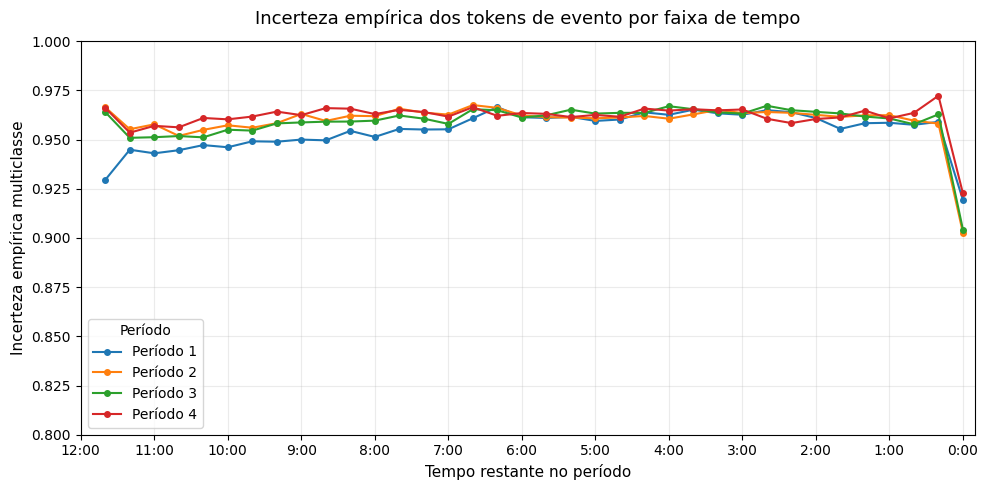

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for period in [1, 2, 3, 4,]:
    df_period = df_plot1.query("period == @period")

    if df_period.empty:
        continue

    label = f"Período {period}"

    ax.plot(
        df_period["t1"],
        df_period["uncertainty_caos"],
        marker="o",
        linewidth=1.5,
        markersize=4,
        label=label
    )

ax.set_title(
    "Incerteza empírica dos tokens de evento por faixa de tempo",
    fontsize=13,
    pad=12
)

ax.set_xlabel("Tempo restante no período", fontsize=11)
ax.set_ylabel("Incerteza empírica multiclasse", fontsize=11)

# Mesmo eixo x do gráfico de incerteza
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Eixo y com zoom controlado
ax.set_ylim(0.8, 1)

ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

plt.tight_layout()

# plt.savefig(
#     "img/media_tokens_tempo_jogo.png",
#     dpi=300,
#     bbox_inches="tight"
# )
#incerteza_empirica_tempo_jogo
plt.show()

In [37]:
season = "2022-23"
str_season = season.replace("-", "")
list_decomposition_time = []
# 1. PREPARAÇÃO DOS DADOS DA TEMPORADA (FORA DO LOOP DE MODELOS)
df_ = df_token_features.query("season == @season").query("season_split == 'train'")\
.query("diff <= -15 & period == 4")

# df_ = df_token_features.query("season == @season").query("season_split == 'train'")\
# .query("diff >= -3 & diff <= 3 & period == 4")

#df_ = df_token_features.query("season == @season").query("season_split == 'train'")
# \
# .assign(token = lambda df: df["target_tokens"].map(integer_to_token))\
# .assign(last_token = lambda df: df.groupby(["game_id", "period"])["token"].shift(1))\
# .query("last_token.notna() & last_token.str.contains('_6\(.{,3}\)$')")

# Processamento temporal feito uma única vez por temporada
df_ = (df_
        .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))
        .pipe(get_match_splits, num_secs = 200))

# # Conversão eficiente de memória
dev_tkn = torch.from_numpy(np.stack(df_["token_features"].values)).to(torch.int64)
dev_num = torch.from_numpy(np.stack(df_["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
dev_y = df_["target_tokens"].values

CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

token_model = NGramModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE,
                num_hidden_neurons = num_hidden_neurons, num_layers = num_layers, activation = nn.GELU,
                dropout_rate = dropout_rate, use_layer_norm = layer_norm)

token_model.load_state_dict(torch.load(models_token_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
token_model.eval()

# 2. INFERÊNCIA
with torch.no_grad():
        # Ajuste condicional para modelos que requerem variáveis numéricas
        output_model = token_model(dev_tkn[:, -CONTEXT_SIZE:])
        all_probs = torch.softmax(output_model, dim = 1).cpu().numpy()

# 3. EXTRAÇÃO POR TEMPO
results_time = []
for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
        res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True) 
        res_df["season_split"] = name[0]
        res_df["period"] = name[1]
        res_df["cat_time"] = name[2]
        results_time.append(res_df)        

df_decomposition_by_time = pd.concat(results_time, ignore_index = True)\
.assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
        set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
        num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
        seasondata = str_season)

list_decomposition_time.append(df_decomposition_by_time)



In [38]:
df_murphy_decomposition_by_time1 = pd.concat(list_decomposition_time, ignore_index = True)

In [39]:
season = "2022-23"
str_season = season.replace("-", "")
list_decomposition_time = []
# 1. PREPARAÇÃO DOS DADOS DA TEMPORADA (FORA DO LOOP DE MODELOS)
# df_ = df_token_features.query("season == @season").query("season_split == 'train'")\
# .query("diff <= -15 & period == 4")

df_ = df_token_features.query("season == @season").query("season_split == 'train'")\
.query("diff >= -3 & diff <= 3 & period == 4")

#df_ = df_token_features.query("season == @season").query("season_split == 'train'")
# \
# .assign(token = lambda df: df["target_tokens"].map(integer_to_token))\
# .assign(last_token = lambda df: df.groupby(["game_id", "period"])["token"].shift(1))\
# .query("last_token.notna() & last_token.str.contains('_6\(.{,3}\)$')")

# Processamento temporal feito uma única vez por temporada
df_ = (df_
        .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))
        .pipe(get_match_splits, num_secs = 200))

# # Conversão eficiente de memória
dev_tkn = torch.from_numpy(np.stack(df_["token_features"].values)).to(torch.int64)
dev_num = torch.from_numpy(np.stack(df_["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
dev_y = df_["target_tokens"].values

CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

token_model = NGramModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE,
                num_hidden_neurons = num_hidden_neurons, num_layers = num_layers, activation = nn.GELU,
                dropout_rate = dropout_rate, use_layer_norm = layer_norm)

token_model.load_state_dict(torch.load(models_token_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
token_model.eval()

# 2. INFERÊNCIA
with torch.no_grad():
        # Ajuste condicional para modelos que requerem variáveis numéricas
        output_model = token_model(dev_tkn[:, -CONTEXT_SIZE:])
        all_probs = torch.softmax(output_model, dim = 1).cpu().numpy()

# 3. EXTRAÇÃO POR TEMPO
results_time = []
for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
        res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True) 
        res_df["season_split"] = name[0]
        res_df["period"] = name[1]
        res_df["cat_time"] = name[2]
        results_time.append(res_df)        

df_decomposition_by_time = pd.concat(results_time, ignore_index = True)\
.assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
        set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
        num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
        seasondata = str_season)

list_decomposition_time.append(df_decomposition_by_time)



In [40]:
df_murphy_decomposition_by_time2 = pd.concat(list_decomposition_time, ignore_index = True)

In [41]:
df_plot1 = df_murphy_decomposition_by_time1\
.groupby(["period", "cat_time"], as_index = False, dropna = False, observed = True)["uncertainty_caos"].sum()\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.sort_values(["period", "t1"], ascending = [True, False])\
.query("period <= 5")\
.reset_index(drop = True)

df_plot2 = df_murphy_decomposition_by_time2\
.groupby(["period", "cat_time"], as_index = False, dropna = False, observed = True)["uncertainty_caos"].sum()\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.sort_values(["period", "t1"], ascending = [True, False])\
.query("period <= 5")\
.reset_index(drop = True)

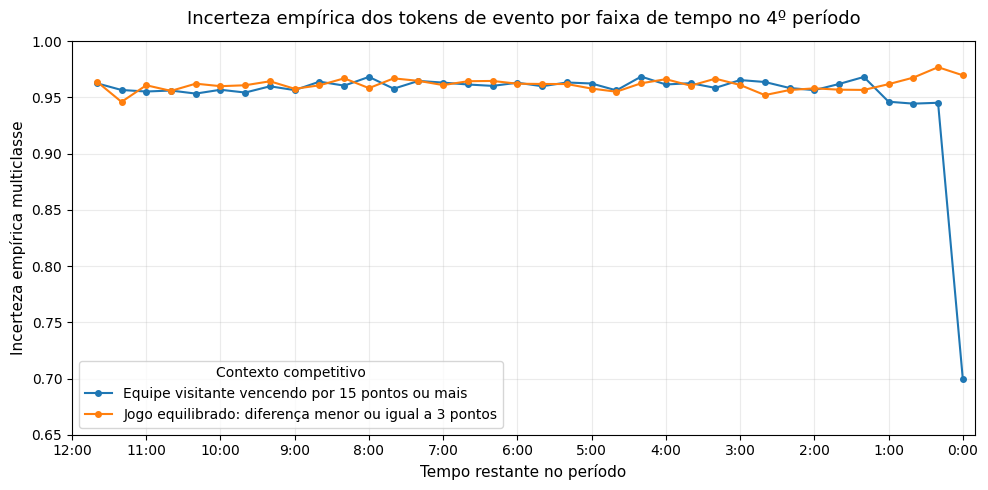

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Criando eixo x numérico em segundos
#df_plot = df_plot.assign(t1_seconds=lambda df: df["t1"] / 10)

ax.plot(df_plot1.query("period <= 4")["t1"],
        df_plot1.query("period <= 4")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label = "Equipe visitante vencendo por 15 pontos ou mais")

#df_plot1 = df_plot1.assign(t1_seconds=lambda df: df["t1"] / 10)

ax.plot(df_plot2.query("period == 4")["t1"],
        df_plot2.query("period == 4")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label = "Jogo equilibrado: diferença menor ou igual a 3 pontos")

# Título e rótulos
ax.set_title(
    "Incerteza empírica dos tokens de evento por faixa de tempo no 4º período",
    fontsize=13,
    pad=12
)

ax.set_xlabel("Tempo restante no período", fontsize=11)
ax.set_ylabel("Incerteza empírica multiclasse", fontsize=11)

# Eixo x em formato de relógio
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Eixo y com zoom controlado
ax.set_ylim(0.65, 1.0)

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Contexto competitivo", frameon=True)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()

# plt.savefig(
#     "img/incerteza_empirica_tempo_jogo.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Grade leve para leitura
ax.grid(True, alpha=0.25)

plt.show()



In [65]:
df_ntokens1 = df_token_features\
.query("season == '2022-23' & season_split == 'train'")\
.query("diff >= -3 & diff <= 3 & period == 4")\
.pipe(func = get_match_splits, num_secs=200)\
.assign(num_games=lambda df: df.groupby(["period", "cat_time"], observed = True)["game_id"].transform("nunique"),
        t1=lambda df: df["cat_time"].str.split("-").str[0].astype(int),
        t1_seconds=lambda df: df["t1"] / 10)\
.groupby(["period", "cat_time", "t1", "t1_seconds", "num_games"], as_index=False, dropna=False, observed=True).size()\
.assign(media_tokens=lambda df: df["size"] / df["num_games"])\
.sort_values(["period", "t1"], ascending=[True, False])

In [82]:
df_ntokens2 = df_token_features\
.query("season == '2022-23' & season_split == 'train'")\
.query("(diff <= -15 or diff >= 15) & period == 4")\
.pipe(func = get_match_splits, num_secs=200)\
.assign(num_games=lambda df: df.groupby(["period", "cat_time"], observed = True)["game_id"].transform("nunique"),
        t1=lambda df: df["cat_time"].str.split("-").str[0].astype(int),
        t1_seconds=lambda df: df["t1"] / 10)\
.groupby(["period", "cat_time", "t1", "t1_seconds", "num_games"], as_index=False, dropna=False, observed=True).size()\
.assign(media_tokens=lambda df: df["size"] / df["num_games"])\
.sort_values(["period", "t1"], ascending=[True, False])

In [73]:
df_ntokens3 = df_token_features\
.query("season == '2022-23' & season_split == 'train'")\
.query("diff >= 15 & period == 4")\
.pipe(func = get_match_splits, num_secs=200)\
.assign(num_games=lambda df: df.groupby(["period", "cat_time"], observed = True)["game_id"].transform("nunique"),
        t1=lambda df: df["cat_time"].str.split("-").str[0].astype(int),
        t1_seconds=lambda df: df["t1"] / 10)\
.groupby(["period", "cat_time", "t1", "t1_seconds", "num_games"], as_index=False, dropna=False, observed=True).size()\
.assign(media_tokens=lambda df: df["size"] / df["num_games"])\
.sort_values(["period", "t1"], ascending=[True, False])

In [78]:
df_ntokens3

,period,cat_time,t1,t1_seconds,num_games,size,media_tokens
35,4,7000-7200,7000,700.0,199,409,2.055276
34,4,6800-7000,6800,680.0,180,396,2.200000
33,4,6600-6800,6600,660.0,194,453,2.335052
32,4,6400-6600,6400,640.0,188,435,2.313830
31,4,6200-6400,6200,620.0,192,440,2.291667
30,4,6000-6200,6000,600.0,183,422,2.306011
29,4,5800-6000,5800,580.0,196,462,2.357143
28,4,5600-5800,5600,560.0,204,464,2.274510
27,4,5400-5600,5400,540.0,202,504,2.495050
26,4,5200-5400,5200,520.0,211,496,2.350711


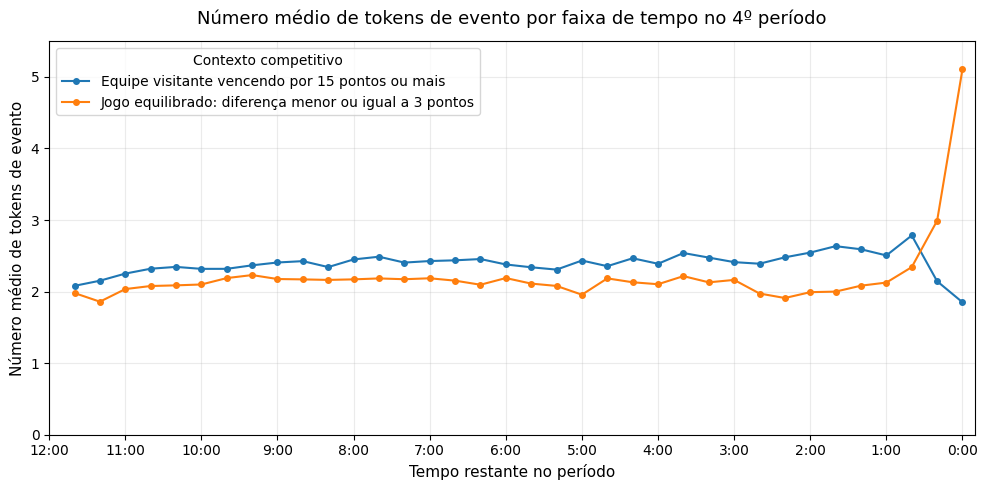

In [84]:
fig, ax = plt.subplots(figsize=(10, 5))

# Criando eixo x numérico em segundos
#df_plot = df_plot.assign(t1_seconds=lambda df: df["t1"] / 10)

ax.plot(df_ntokens2["t1_seconds"], df_ntokens2["media_tokens"],
        marker="o", linewidth=1.5, markersize=4, label = "Equipe visitante vencendo por 15 pontos ou mais")

#df_plot1 = df_plot1.assign(t1_seconds=lambda df: df["t1"] / 10)

ax.plot(df_ntokens1["t1_seconds"], df_ntokens1["media_tokens"],
        marker="o", linewidth=1.5, markersize=4, label = "Jogo equilibrado: diferença menor ou igual a 3 pontos")

# ax.plot(df_ntokens3["t1_seconds"], df_ntokens3["media_tokens"],
#         marker="o", linewidth=1.5, markersize=4, label = "Equipe mandante vencendo por 15 pontos ou mais")

# Título e rótulos
ax.set_title(
    "Número médio de tokens de evento por faixa de tempo no 4º período",
    fontsize=13,
    pad=12
)

ax.set_xlabel("Tempo restante no período", fontsize=11)
ax.set_ylabel("Número médio de tokens de evento", fontsize=11)

# Eixo x em formato de relógio
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Eixo y com zoom controlado
ax.set_ylim(0, 5.5)

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Contexto competitivo", frameon=True)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()

# plt.savefig(
#     "img/incerteza_empirica_tempo_jogo.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Grade leve para leitura
ax.grid(True, alpha=0.25)

plt.show()



In [ ]:
numerical_vector = np.column_stack([
    period_list,      # 5 colunas
    rt_ratio,         # 1
    timeout_home,     # 1
    timeout_away,     # 1
    diff_30,          # 1
    t600,             # 1
    t200,             # 1
    t100,             # 1
    t50,              # 1
    t10,              # 1
    leading,          # 1
    bp,               # 1
])

numerical_vector = np.column_stack([
    timeout_home,     # 1
    timeout_away,     # 1
    ind_close_3,      # 1
    ind_close_5,      # 1
    ind_close_8,      # 1
    ind_blowout_15,   # 1
    t1200,            # 1
    t600,             # 1
    t200,             # 1
    t100,             # 1
    t50,              # 1
    t10,              # 1
    home_leading,     # 1
    away_leading,     # 1
    bp,               # 1
    period_list,      # 5 colunas
    rt_ratio,         # 1
    diff_20           # 1            
]) 

In [ ]:
numerical_vector = np.column_stack([
    period_list,      # 5 colunas
    rt_ratio,         # 1
    timeout_home,     # 1
    timeout_away,     # 1
    diff_20,          # 1
    ind_close_3,      # 1
    ind_close_5,      # 1
    ind_close_8,      # 1
    ind_blowout_15,   # 1
    t1200,            # 1
    t600,             # 1
    t200,             # 1
    t100,             # 1
    t50,              # 1
    t10,              # 1
    home_leading,     # 1
    away_leading,     # 1
    t1200_game,       # 1
    t600_game,        # 1
    t200_game,        # 1
    t100_game,        # 1
    t50_game,         # 1
    ind_clutch_2_last_minutes,       # 1 
    ind_clutch_2_last_minutes_home,  # 1 
    ind_clutch_2_last_minutes_away,  # 1 
    ind_clutch_last_minute,          # 1 
    ind_clutch_last_minute_home,     # 1 
    ind_clutch_last_minute_away,     # 1 
    ind_clutch_last_20_seconds,      # 1 
    ind_clutch_last_20_seconds_home, # 1 
    ind_clutch_last_20_seconds_away, # 1 
    ind_clutch_last_10_seconds,      # 1 
    ind_clutch_last_10_seconds_home, # 1 
    ind_clutch_last_10_seconds_away, # 1 
    ind_blowout_last_minute,         # 1 
    bp,               # 1
])

In [ ]:
numerical_vector = np.column_stack([
    timeout_home,     # 1
    timeout_away,     # 1
    ind_close_3,      # 1
    ind_close_5,      # 1
    ind_close_8,      # 1
    ind_blowout_15,   # 1
    t1200,            # 1
    t600,             # 1
    t200,             # 1
    t100,             # 1
    t50,              # 1
    t10,              # 1
    home_leading,     # 1
    away_leading,     # 1
    bp,               # 1
    period_list,      # 5 colunas
    rt_ratio,         # 1
    diff_20           # 1            
]) 

In [ ]:


fig, ax = plt.subplots(figsize=(10, 5))

for period in [1, 2, 3, 4]:
    df_period = df_plot_tokens.query("period == @period")

    if df_period.empty:
        continue

    label = f"Período {period}"

    ax.plot(
        df_period["t1_seconds"],
        df_period["media_tokens"],
        marker="o",
        linewidth=1.5,
        markersize=4,
        label=label
    )

ax.set_title(
    "Número médio de tokens de evento por faixa de tempo",
    fontsize=13,
    pad=12
)

ax.set_xlabel("Tempo restante no período", fontsize=11)
ax.set_ylabel("Número médio de tokens de evento", fontsize=11)

# Mesmo eixo x do gráfico de incerteza
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Eixo y com zoom controlado
ax.set_ylim(0, 5.5)

ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

plt.tight_layout()

# plt.savefig(
#     "img/media_tokens_tempo_jogo.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [28]:
df_plot1

,period,cat_time,uncertainty_caos,t1
0,1,7000-7200,0.929530,7000
1,1,6800-7000,0.944836,6800
2,1,6600-6800,0.943005,6600
3,1,6400-6600,0.944588,6400
4,1,6200-6400,0.947184,6200
...,...,...,...,...
154,5,800-1000,0.958584,800
155,5,600-800,0.958988,600
156,5,400-600,0.965960,400
157,5,200-400,0.971588,200


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Criando eixo x numérico em segundos
df_plot = df_plot.assign(t1_seconds=lambda df: df["t1"] / 10)

ax.plot(df_plot.query("period == 4")["t1_seconds"],
        df_plot.query("period == 4")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label = "Equipe mandante perdendo por 15 pontos ou mais")

df_plot1 = df_plot1.assign(t1_seconds=lambda df: df["t1"] / 10)

ax.plot(df_plot1.query("period == 4")["t1_seconds"],
        df_plot1.query("period == 4")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label = "Jogo equilibrado: diferença entre -3 e 3 pontos")

# Título e rótulos
ax.set_title(
    "Incerteza empírica dos tokens de evento por faixa de tempo no 4º período",
    fontsize=13,
    pad=12
)

ax.set_xlabel("Tempo restante no período", fontsize=11)
ax.set_ylabel("Incerteza empírica multiclasse", fontsize=11)

# Eixo x em formato de relógio
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Eixo y com zoom controlado
ax.set_ylim(0.7, 1.0)

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Contexto competitivo", frameon=True)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()

# plt.savefig(
#     "img/incerteza_empirica_tempo_jogo.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Grade leve para leitura
ax.grid(True, alpha=0.25)

plt.show()


In [ ]:
def format_time_seconds(x, pos=None):
    x = int(round(x))
    minutes = x // 60
    seconds = x % 60
    return f"{minutes}:{seconds:02d}"


df_plot_tokens = (
    df_token_features
    .query("season == '2018-19' & season_split == 'dev' & diff <= -15")
    .query("period == 4")
    .pipe(func=get_match_splits, num_secs=200)
    .assign(
        num_games=lambda df: df.groupby("period")["game_id"].transform("nunique"),
        t1=lambda df: df["cat_time"].str.split("-").str[0].astype(int),
        t1_seconds=lambda df: df["t1"] / 10
    )
    .groupby(
        ["period", "cat_time", "t1", "t1_seconds", "num_games"],
        as_index=False,
        dropna=False,
        observed=True
    )
    .size()
    .assign(media_tokens=lambda df: df["size"] / df["num_games"])
    .sort_values(["period", "t1"], ascending=[True, False])
)

df_plot_tokens1 = (
    df_token_features
    .query("season == '2018-19' & season_split == 'dev' & diff >= -3 & diff <= 3")
    .query("period == 4")
    .pipe(func=get_match_splits, num_secs=200)
    .assign(
        num_games=lambda df: df.groupby("period")["game_id"].transform("nunique"),
        t1=lambda df: df["cat_time"].str.split("-").str[0].astype(int),
        t1_seconds=lambda df: df["t1"] / 10
    )
    .groupby(
        ["period", "cat_time", "t1", "t1_seconds", "num_games"],
        as_index=False,
        dropna=False,
        observed=True
    )
    .size()
    .assign(media_tokens=lambda df: df["size"] / df["num_games"])
    .sort_values(["period", "t1"], ascending=[True, False])
)


fig, ax = plt.subplots(figsize=(10, 5))

label = f"Equipe mandante perdendo por 15 pontos ou mais"

ax.plot(
df_plot_tokens["t1_seconds"],
df_plot_tokens["media_tokens"],
marker="o",
linewidth=1.5,
markersize=4,
label=label
)

label = "Jogo equilibrado: diferença entre -3 e 3 pontos"

ax.plot(
df_plot_tokens1["t1_seconds"],
df_plot_tokens1["media_tokens"],
marker="o",
linewidth=1.5,
markersize=4,
label=label
)

ax.set_title(
    "Número médio de tokens de evento por faixa de tempo no 4º período",
    fontsize=13,
    pad=12
)

ax.set_xlabel("Tempo restante no período", fontsize=11)
ax.set_ylabel("Número médio de tokens de evento", fontsize=11)

# Mesmo eixo x do gráfico de incerteza
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Eixo y com zoom controlado
ax.set_ylim(0, 4)

ax.grid(True, alpha=0.25)
ax.legend(title="Contexto competitivo", frameon=True)

plt.tight_layout()

# plt.savefig(
#     "img/media_tokens_tempo_jogo.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [ ]:
import matplotlib.ticker as mticker

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Criando eixo x numérico em segundos
df_plot = df_plot.assign(t1_seconds=lambda df: df["t1"] / 10)

ax.plot(df_plot.query("period == 1")["t1_seconds"],
        df_plot.query("period == 1")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label="Período 1")

ax.plot(df_plot.query("period == 2")["t1_seconds"],
        df_plot.query("period == 2")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label="Período 2")

ax.plot(df_plot.query("period == 3")["t1_seconds"],
        df_plot.query("period == 3")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label="Período 3")

ax.plot(df_plot.query("period == 4")["t1_seconds"],
        df_plot.query("period == 4")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label="Período 4")

ax.plot(df_plot.query("period == 5")["t1_seconds"],
        df_plot.query("period == 5")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label="Período 5")

# Título e rótulos
ax.set_title(
    "Incerteza empírica dos tokens de evento por faixa de tempo",
    fontsize=13,
    pad=12
)

ax.set_xlabel("Tempo restante no período", fontsize=11)
ax.set_ylabel("Incerteza empírica multiclasse", fontsize=11)

# Eixo x em formato de relógio
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Eixo y com zoom controlado
#ax.set_ylim(0.8, 1.0)

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()

# plt.savefig(
#     "img/incerteza_empirica_tempo_jogo.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Grade leve para leitura
ax.grid(True, alpha=0.25)

plt.show()

In [ ]:


df_plot = df_murphy_decomposition_by_time.iloc[[3]]\
[["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "seasondata"]]\
.merge(df_murphy_decomposition_by_time, how = "inner")\
.assign(token = lambda df: df["token_id"].map(integer_to_token))\
.query("token.str.contains('p..._8\(')" )\
.groupby(["period", "cat_time"], as_index = False, dropna = False, observed = True)["uncertainty_caos"].sum()\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int"))\
.sort_values(["period", "t1"], ascending = [True, False])\
.query("period <= 5")\
.reset_index(drop = True)

# Função para formatar segundos como mm:ss
def format_time_seconds(x, pos=None):
    x = int(round(x))
    minutes = x // 60
    seconds = x % 60
    return f"{minutes}:{seconds:02d}"


fig, ax = plt.subplots(figsize=(10, 5))

# Criando eixo x numérico em segundos
df_plot = df_plot.assign(t1_seconds=lambda df: df["t1"] / 10)

ax.plot(df_plot.query("period == 1")["t1_seconds"],
        df_plot.query("period == 1")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label="Período 1")

ax.plot(df_plot.query("period == 2")["t1_seconds"],
        df_plot.query("period == 2")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label="Período 2")

ax.plot(df_plot.query("period == 3")["t1_seconds"],
        df_plot.query("period == 3")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label="Período 3")

ax.plot(df_plot.query("period == 4")["t1_seconds"],
        df_plot.query("period == 4")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label="Período 4")

ax.plot(df_plot.query("period == 5")["t1_seconds"],
        df_plot.query("period == 5")["uncertainty_caos"],
        marker="o", linewidth=1.5, markersize=4, label="Período 5")

# Título e rótulos
ax.set_title(
    "Incerteza empírica dos tokens de evento por faixa de tempo",
    fontsize=13,
    pad=12
)

ax.set_xlabel("Tempo restante no período", fontsize=11)
ax.set_ylabel("Incerteza empírica multiclasse", fontsize=11)

# Eixo x em formato de relógio
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Eixo y com zoom controlado
#ax.set_ylim(0.8, 1.0)

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()

# plt.savefig(
#     "img/incerteza_empirica_tempo_jogo.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Grade leve para leitura
ax.grid(True, alpha=0.25)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def desenhar_quadra_nba(ax=None, cor='black'):
    if ax is None:
        ax = plt.gca()

    # --- 1. Linhas Retas (Limites e Garrafão) ---
    # Linha de fundo e laterais (Meio campo)
    ax.plot([-250, 250, 250, -250, -250], [-52.5, -52.5, 417.5, 417.5, -52.5], color=cor)

    # Garrafão (The Paint)
    ax.plot([-80, 80, 80, -80, -80], [-52.5, -52.5, 137.5, 137.5, -52.5], color=cor)

    # Tabela (Backboard)
    ax.plot([-30, 30], [-40, -40], color=cor)

    # --- 2. Linha de Três Pontos ---
    # Retas laterais do Corner 3 (param em y = 87.5)
    ax.plot([-220, -220], [-52.5, 87.5], color=cor)
    ax.plot([220, 220], [-52.5, 87.5], color=cor)

    # Arco de 3 (Raio 237.5)
    # Calculamos o ângulo onde o arco encontra as retas laterais
    angulo_canto = np.arcsin(87.5 / 237.5)
    angulos_arco = np.linspace(angulo_canto, np.pi - angulo_canto, 100)

    x_arco = 237.5 * np.cos(angulos_arco) # Nota: inverti cos/sin para alinhar com o eixo Y
    y_arco = 237.5 * np.sin(angulos_arco)

    # Como o arco é centrado em (0,0), plotamos direto
    ax.plot(x_arco, y_arco, color=cor)

    # --- 3. Círculos (Aro e Lance Livre) ---
    def plot_circulo(centro_x, centro_y, raio, theta_inicio=0, theta_fim=2*np.pi):
        t = np.linspace(theta_inicio, theta_fim, 100)
        ax.plot(centro_x + raio * np.cos(t), centro_y + raio * np.sin(t), color=cor)

    # Aro (Raio 7.5)
    plot_circulo(0, 0, 7.5)

    # Semicírculo de Restrição (Raio 40)
    plot_circulo(0, 0, 40, 0, np.pi)

    # Círculo do Lance Livre (Raio 60, centrado na linha de lance livre)
    plot_circulo(0, 137.5, 60)

    # --- Configurações de Exibição ---
    ax.set_aspect('equal')
    ax.set_xlim(-260, 260)
    ax.set_ylim(-70, 430)
    ax.axis('off')

# --- Teste com arremessos ---
plt.figure(figsize=(8, 7))
desenhar_quadra_nba()

# Exemplo de dados Sportradar: x=0, y=0 (Cesta); x=230, y=0 (Corner 3)

#plt.scatter(arremessos_x, arremessos_y, color='red', s=40, zorder=5)

plt.show()

In [ ]:
pbpa_2022_23 = pd.read_parquet("C:/Users/User/Documents/recuperacao_arquivoshd/Mestrado/NBA/nba/data/processed/pbp_season_files/api/pbpa_2022_23.parquet")
pbp_2022_23 = pd.read_parquet("C:/Users/User/Documents/recuperacao_arquivoshd/Mestrado/NBA/nba/data/processed/pbp_season_files/concatenate_data/pbp_2022_23.parquet")

In [ ]:
# 1629029 >> doncic
# 201939 >> curry
# 203497 >> gobert
# 203507 >> gianis ante

p1_code = '1629029'
p2_code = '203497'

player1_made_shots = pbpa_2022_23\
.query("PLAYER1_ID == @p1_code & EVENTMSGTYPE == '1'")[["GAME_ID", "EVENTNUM"]]\
.rename(columns = {"GAME_ID": "game_id", "EVENTNUM": "num_event"})\
.astype({"num_event": "int"})\
.merge(pbp_2022_23, how = "inner")

player1_missed_shots = pbpa_2022_23\
.query("PLAYER1_ID == @p1_code & EVENTMSGTYPE == '2'")[["GAME_ID", "EVENTNUM"]]\
.rename(columns = {"GAME_ID": "game_id", "EVENTNUM": "num_event"})\
.astype({"num_event": "int"})\
.merge(pbp_2022_23, how = "inner")

player2_made_shots = pbpa_2022_23\
.query("PLAYER1_ID == @p2_code & EVENTMSGTYPE == '1'")[["GAME_ID", "EVENTNUM"]]\
.rename(columns = {"GAME_ID": "game_id", "EVENTNUM": "num_event"})\
.astype({"num_event": "int"})\
.merge(pbp_2022_23, how = "inner")

player2_missed_shots = pbpa_2022_23\
.query("PLAYER1_ID == @p2_code & EVENTMSGTYPE == '2'")[["GAME_ID", "EVENTNUM"]]\
.rename(columns = {"GAME_ID": "game_id", "EVENTNUM": "num_event"})\
.astype({"num_event": "int"})\
.merge(pbp_2022_23, how = "inner")




#.query("PLAYER1_NAME.notna() & PLAYER1_NAME.str.contains('Curry')")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 8)) # Aumentei um pouco a altura para a legenda

desenhar_quadra_nba(ax=ax[0])
desenhar_quadra_nba(ax=ax[1])

# Plotagem Luka (zorder positivo para ficar sobre as linhas)

made1 = ax[0].scatter(player1_made_shots["xlegacy"], player1_made_shots["ylegacy"],
                     color='royalblue', s=40, zorder=-4, alpha=0.8, label='Acerto')
missed1 = ax[0].scatter(player1_missed_shots["xlegacy"], player1_missed_shots["ylegacy"],
                       color='tomato', s=25, zorder=-3, alpha=0.6, label='Erro')
# Plotagem Gobert

ax[1].scatter(player2_made_shots["xlegacy"], player2_made_shots["ylegacy"],
              color='royalblue', s=40, zorder=-4, alpha=0.8)
ax[1].scatter(player2_missed_shots["xlegacy"], player2_missed_shots["ylegacy"],
              color='tomato', s=25, zorder=-3, alpha=0.6)
# Títulos
ax[0].set_title("Localização de arremessos do Luka Dončić", fontsize=14, pad=15)
ax[1].set_title("Localização de arremessos do Rudy Gobert", fontsize=14, pad=15)

# --- 1. Legenda Centralizada ---
# Criamos uma legenda única para a figura toda na parte inferior
fig.legend([made1, missed1], ['Arremesso Certo', 'Arremesso Errado'],
           loc='lower center', ncol=2, fontsize=12, frameon=True, bbox_to_anchor=(0.5, 0.1))

plt.subplots_adjust(wspace=0.05, left=0.05, right=0.95, bottom=0.15)

# --- 2. Ajuste de Margens e Layout ---
plt.tight_layout(rect=[0, 0.1, 1, 0.95]) # Abre espaço embaixo (0.1) para a legenda

ax[0].text(
    0.5, 1.00, "Temporada 2022/23",
    transform=ax[0].transAxes,
    ha="center",
    va="bottom",
    fontsize=10)

ax[1].text(
    0.5, 1.00, "Temporada 2022/23",
    transform=ax[1].transAxes,
    ha="center",
    va="bottom",
    fontsize=10,

)

info_player1 = (
    "\n"
    "Jogos na temporada: 66\n"
    "Total de arremessos: 1449\n"
    "Conversão (%): 49.62%"
)

info_player2 = (
    "\n"
    "Jogos na temporada: 76\n"
    "Total de arremessos: 603\n"
    "Conversão (%): 65.50%"
)

ax[0].text(
    0.04, 0.97, info_player1,
    transform=ax[0].transAxes,
    ha="left",
    va="top",
    fontsize=10
)

ax[1].text(
    0.04, 0.97, info_player2,
    transform=ax[1].transAxes,
    ha="left",
    va="top",
    fontsize=10
)

# --- 3. Dica para Salvar com Alta Qualidade ---
# plt.savefig("comparativo_arremessos.pdf", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:

pbp_tokenized = pd.read_csv(data_folder + "pbp_tokenized.txt", sep = ";")
df_games_nba = pd.read_csv(data_folder + "games_nba.csv", sep = ';')\
.rename(columns = {"GAME_ID": "game_id", "SEASON": "season"})\
.assign(season = lambda df: df["season"].str.replace("\-", "", regex = True))

full_pbp_tokenized = pbp_tokenized\
.merge(df_games_nba[["game_id", "season"]].drop_duplicates(), how = "left")\
.assign(tp_token = lambda df: df["token"].str.replace("\)p", ");p", regex = True).str.replace("p[0-9]{3}_", "", regex = True))\
.assign(tp_token = lambda df: df["tp_token"].str.replace("\(.+?\)", "", regex = True).str.split(";"))\
.assign(token_int = lambda df: df["token"].map(token_to_integer))

del pbp_tokenized

In [ ]:
xdf = full_pbp_tokenized\
.assign(tp = lambda df: df["token"].str.replace("p[0-9]{3}_", "", regex = True))\
.assign(tp = lambda df: df["tp"].str.replace("\)", ");", regex = True).str.replace(";$", "", regex = True))\
.assign(tp = lambda df: df["tp"].str.split(";"))

In [ ]:
xdf2 = pd.concat([
    pd.DataFrame(xdf["tp_token"].to_list(), index = xdf.index).stack().reset_index().rename(columns = {0: "tp_event"}).set_index("level_0")[["tp_event"]].reset_index(),
    pd.DataFrame(xdf["tp"].to_list()).stack().reset_index().rename(columns = {0: "tp_subevent"})[["tp_subevent"]]
    ], axis = 1, ignore_index = False)




In [ ]:
xdf3 = xdf2.set_index("level_0")\
.merge(full_pbp_tokenized[["clock", "period", "game_id"]], how = "left", left_index = True, right_index = True)\
.assign(intclock = lambda df: df["clock"].str.split(":").str[0].astype(int) * 600)\
.assign(intclock = lambda df: df["intclock"] + df["clock"].str.split(":").str[1].astype(int) * 10)\
.assign(intclock = lambda df: df["intclock"] + (df["clock"].str.split(":").str[2].astype(int) / 10))

In [ ]:
counts_after_bpe.mean(), counts_after_bpe.std(), counts_after_bpe.std() / counts_after_bpe.mean()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

counts_before_bpe = (
    xdf3
    .groupby(["game_id", "period"], dropna=False)
    .size()
    .reset_index(name="n_events")
    .query("period <= 4")["n_events"]
)

counts_after_bpe = (
    full_pbp_tokenized
    .groupby(["game_id", "period"], dropna=False)
    .size()
    .reset_index(name="n_tokens")
    .query("period <= 4")["n_tokens"]
)

xmin = min(counts_before_bpe.min(), counts_after_bpe.min())
xmax = max(counts_before_bpe.max(), counts_after_bpe.max())

bins = np.arange(xmin - 0.5, xmax + 1.5, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.hist(
    counts_before_bpe,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Antes do BPE"
)

ax.hist(
    counts_after_bpe,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Após o BPE"
)

ax.set_xlim(60, 160)
ax.set_xlabel("Quantidade por período")
ax.set_ylabel("Densidade")
ax.set_title("Distribuição da quantidade de eventos por período antes e após o BPE")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.set_xticks([i for i in range(60, 165, 5)])

plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------
# 1) Distribuição do número de tokens entre cestas convertidas
#    (contando a cesta convertida que abre a sequência)
# --------------------------------------------------
dist_cestas = (
    full_pbp_tokenized
    .assign(
        ind_arremesso_correto=lambda df: df["token"].str.contains(r"_1\(").astype(int)
    )
    .assign(
        bloco_pos_cesta=lambda df: df.groupby(["game_id", "period"])["ind_arremesso_correto"].cumsum()
    )
    .groupby(["game_id", "period", "bloco_pos_cesta"], as_index=False)
    .size()
    .rename(columns={"size": "num_tokens"})
    .query("bloco_pos_cesta > 0")
    .groupby("num_tokens", as_index=False)
    .size()
    .rename(columns={"size": "n_sequencias"})
    .sort_values("num_tokens")
)

# --------------------------------------------------
# 2) Agrupar todos os valores >= 20 em "20+"
# --------------------------------------------------
dist_cestas_plot = (
    dist_cestas
    .assign(num_tokens_plot=lambda df: df["num_tokens"].where(df["num_tokens"] < 20, 20))
    .groupby("num_tokens_plot", as_index=False)["n_sequencias"].sum()
    .sort_values("num_tokens_plot")
    .assign(
        perc=lambda df: 100 * df["n_sequencias"] / df["n_sequencias"].sum(),
        percacm=lambda df: 100 * df["n_sequencias"].cumsum() / df["n_sequencias"].sum()
    )
)

# estatísticas úteis
media = (dist_cestas["num_tokens"] * dist_cestas["n_sequencias"]).sum() / dist_cestas["n_sequencias"].sum()
mediana = (
    dist_cestas
    .assign(percacm=lambda df: 100 * df["n_sequencias"].cumsum() / df["n_sequencias"].sum())
    .loc[lambda df: df["percacm"] >= 50, "num_tokens"]
    .iloc[0]
)

y5 = dist_cestas_plot.loc[dist_cestas_plot["num_tokens_plot"] == 5, "percacm"].iloc[0]

print(f"Média: {media:.2f}")
print(f"Mediana: {mediana}")
print(f"% até 5 tokens: {y5:.2f}")

# --------------------------------------------------
# 3) Gráfico acumulado com categoria final "20+"
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

x = dist_cestas_plot["num_tokens_plot"]
y = dist_cestas_plot["percacm"]

ax.step(x, y, where="post", linewidth=1.8)
ax.scatter([5], [y5], zorder=5)

ax.axvline(5, linestyle="--", color="gray", zorder=-3)
ax.axhline(y5, linestyle="--", color="gray", zorder=-3)

ax.annotate(
    f"5 tokens: {y5:.1f}%",
    xy=(5, y5),
    xytext=(7, y5 - 12),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.set_xlim(1, 20)
ax.set_ylim(0, 100)

ticks = list(range(1, 20)) + [20]
labels = [str(i) for i in range(1, 20)] + ["20+"]
ax.set_xticks(ticks)
ax.set_xticklabels(labels)

ax.set_title("Distribuição acumulada do número de tokens entre arremessos convertidos")
ax.set_xlabel("Número de tokens na sequência")
ax.set_ylabel("Percentual acumulado (%)")

ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
xdf4 = xdf3\
.assign(lasttime = lambda df: df.groupby(["game_id", "period"])["intclock"].shift(1))\
.query("lasttime.notna()")\
.assign(diftime = lambda df: df["lasttime"] - df["intclock"])\
.assign(diftime = lambda df: df["diftime"].astype("int"))

In [ ]:
df = (
    pd.read_csv("../data/juncoes_bpe.csv", sep=";")
    .sort_values("passo")
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df["passo"], df["freq"], linewidth=1.5)

# Passos do algoritmo correspondentes aos tamanhos do vocabulário
marcos = {
    36: "300 tokens",
    340: "600 tokens",
    642: "900 tokens",
    923: "1200 tokens",
    1246: "1500 tokens"
}

for x, label in marcos.items():
    ax.axvline(x, linestyle="--", color="gray", zorder=-3)
    ax.text(
        x + 5,
        df["freq"].max() * 0.9,
        label,
        rotation=90,
        va="top",
        ha="left",
        fontsize=9,
        color="gray"
    )

# # Destacar o ponto de interesse, se quiser
passo_escolhido = 340   # ajuste se o ponto adotado for outro
freq_escolhida = df.loc[df["passo"] == passo_escolhido, "freq"]
# if not freq_escolhida.empty:
ax.scatter([passo_escolhido], [freq_escolhida.iloc[0]], zorder=5)
#     ax.annotate(
#         "Escolha adotada",
#         xy=(passo_escolhido, freq_escolhida.iloc[0]),
#         xytext=(passo_escolhido + 40, freq_escolhida.iloc[0] * 1.5),
#         arrowprops=dict(arrowstyle="->"),
#         fontsize=10
#     )

ax.set_yscale("log")

ax.set_xlim(0, df["passo"].max())
ax.set_xticks([0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200])

ax.set_title("Evolução da Frequência Marginal de Fusões (Adaptação BPE)")
ax.set_xlabel("Passo do algoritmo BPE")
ax.set_ylabel("Frequência Marginal de Fusão (Escala Logarítmica)")

ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:

xdf4_plot = xdf4.query("~clock.str.contains('^00\:')").copy()
xdf5_plot = xdf5.query("~clock.str.contains('^00\:')").copy()

def prepare_freq(df, max_sec = 30):
    # diftime está em décimos de segundo
    sec = (df["diftime"] // 10).astype(int)

    # agrupa valores > 35 segundos em uma categoria residual
    sec_group = np.where(sec > max_sec, max_sec + 1, sec)

    cats = list(range(0, max_sec + 2))   # 0,1,2,...,35,36
    freq = (
        pd.Series(pd.Categorical(sec_group, categories=cats, ordered=True))
        .value_counts(normalize=False)
        .sort_index()
    )

    labels = [str(i) for i in range(0, max_sec + 1)] + [f"{max_sec}+"]
    return freq.values, labels

freq_before, labels = prepare_freq(xdf4_plot, max_sec=30)
freq_after, _      = prepare_freq(xdf5_plot, max_sec=30)

x = np.arange(len(labels))
width = 0.42

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - width/2, freq_before, width=width, label="Antes da agregação")
ax.bar(x + width/2, freq_after,  width=width, label="Após a agregação")

ax.set_ylabel("Frequência absoluta")
ax.set_xlabel("Tempo gasto entre tokens de evento (segundos)")
ax.set_title("Distribuição empírica do tempo gasto entre tokens de evento")

# mostra só alguns rótulos para não poluir
tick_idx = list(range(0, 31, 1)) + [31]
tick_labels = [labels[i] for i in tick_idx]
ax.set_xticks(tick_idx)
ax.set_xticklabels(tick_labels)

ax.set_xlim(-0.6, len(labels) - 0.4)
ax.legend(frameon=False)

plt.tight_layout()
#plt.savefig("dist_tempo_barplot_antes_depois.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
xdf5 = full_pbp_tokenized\
.assign(intclock = lambda df: df["clock"].str.split(":").str[0].astype(int) * 600)\
.assign(intclock = lambda df: df["intclock"] + df["clock"].str.split(":").str[1].astype(int) * 10)\
.assign(intclock = lambda df: df["intclock"] + (df["clock"].str.split(":").str[2].astype(int) / 10))\
.assign(lasttime = lambda df: df.groupby(["game_id", "period"])["intclock"].shift(1))\
.query("lasttime.notna()")\
.assign(diftime = lambda df: df["lasttime"] - df["intclock"])\
.assign(diftime = lambda df: df["diftime"].astype("int"))

In [ ]:
full_pbp_tokenized\
[["token"]].value_counts().reset_index()\
.assign(n = lambda df: df["token"].str.count("_"))\
.query("n == 6")["token"].to_list()

In [ ]:
xdf2.astype({"tp_event": "int"}).groupby(["tp_event", "tp_subevent"], as_index = False).size()\
.iloc[120:]

In [ ]:
data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
with open(data_folder + 'prop_end_period_by_remaining_time.pkl', 'rb') as f:
    dict_prop_end_period_remaining_time = pickle.load(f)

In [ ]:
# season_key = "201819"
mat = dict_prop_end_period_remaining_time[season_key]

# eixo x em segundos
x_sec = np.arange(301) / 10

# curvas selecionadas
y_p1 = mat[0]   # 1º período
y_p4 = mat[3]   # 4º período
y_ot = mat[4]   # overtime agregado

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(x_sec, y_p1, linewidth=2, label="1º período")
ax.plot(x_sec, y_p4, linewidth=2, label="4º período")
ax.plot(x_sec, y_ot, linewidth=2, label="Overtime")

# eixo invertido: 30s -> 0s
ax.set_xlim(30, 0)
ax.set_ylim(0, 1)

ax.set_xticks(np.arange(30, -1, -5))
ax.set_xticklabels([f"{v}s" for v in np.arange(30, -1, -5)])

ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.set_yticklabels([f"{v:.1f}" for v in np.arange(0, 1.01, 0.1)])

ax.set_xlabel("Tempo restante no período (segundos)")
ax.set_ylabel("Proporção acumulada")

ax.set_title(
    "Tempo restante no período quando surgiu um token de encerramento",
    fontsize=12,
    pad=12
)

ax.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

ax.legend(
    loc="upper left",
    title="Temporada 2018/19",
    frameon=True
)

plt.tight_layout()
plt.show()